In [26]:
from resonance.api import Beamline, ScanPlan

In [27]:
bl = await Beamline.create()

In [28]:
await bl.ai.trigger_and_read(["AI 3 Izero"], 0.002)

{'AI 3 Izero': -0.0202942833139038+/-0.002790758127334277}

In [29]:
await bl._conn.get_freerun(["AI 3 Izero"])

{'chans': ['AI 3 Izero'],
 'not found': [],
 'data': [-0.0169048569581505],
 'success': True,
 'error description': 'no error',
 'log?': False,
 'API_delta_t': 0.010069847106933594}

In [19]:
r = await bl._conn.get_freerun_array(["AI 3 Izero"])

In [38]:
import asyncio
import numpy as np
from time import perf_counter


def avg(r):
    data = np.mean(r["chans"][0]["data"])
    return data

df_list = []

start = perf_counter()
while True:
    ts = perf_counter()
    array_value = (await bl._conn.get_freerun_array(["AI 3 Izero"]))["chans"][0]["data"]
    freerun_value = (await bl._conn.get_freerun(["AI 3 Izero"]))["data"][0]
    df_list.append(
        {
            "ts": ts - start,
            "array_value": array_value,
            "freerun_value": freerun_value,
        }
    )
    await asyncio.sleep(0.0001)

CancelledError: 

In [41]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

df = pd.DataFrame(df_list)
df

,ts,array_value,freerun_value
0,0.000203,"[-0.0228421062269381, -0.00180202020704225, -0...",-0.017697
1,0.037237,"[-0.0136370686088325, -0.0149520739843163, -0....",-0.017768
2,0.068305,"[-0.0136370686088325, -0.0149520739843163, -0....",-0.017768
3,0.100320,"[-0.0136370686088325, -0.0149520739843163, -0....",-0.017768
4,0.132364,"[-0.0136370686088325, -0.0149520739843163, -0....",-0.017322
...,...,...,...
1762,55.303049,"[-0.0320471438214139, -0.0175820847338084, -0....",-0.018125
1763,55.334005,"[-0.0320471438214139, -0.0175820847338084, -0....",-0.018055
1764,55.364971,"[-0.0274446250270935, -0.0195545927946432, -0....",-0.018055
1765,55.395878,"[-0.0274446250270935, -0.0195545927946432, -0....",-0.018055


C:\Users\Admin\AppData\Local\Temp\ipykernel_23556\829235808.py:48: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Admin\auto-reflect\.venv\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\Admin\auto-reflect\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


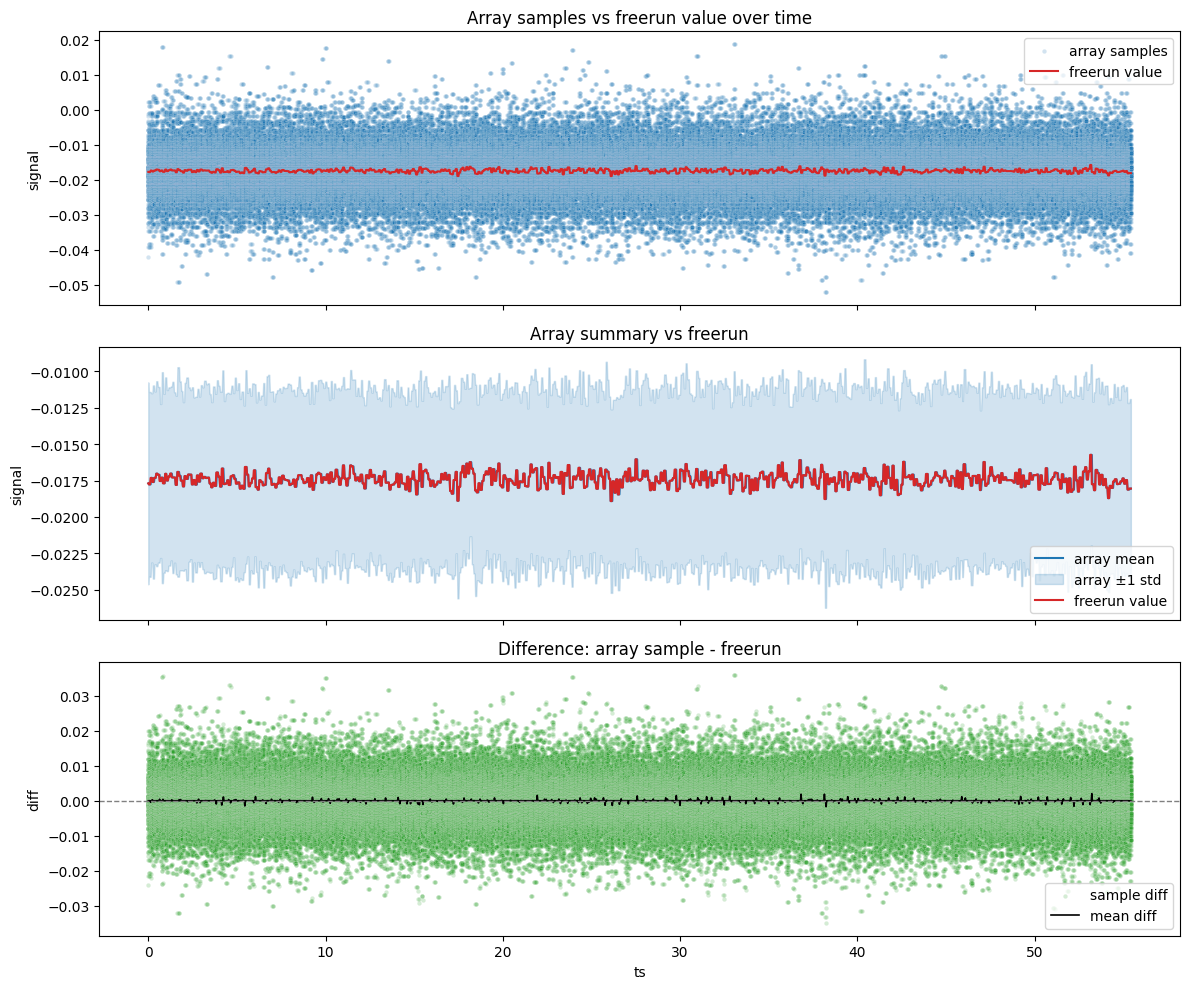

In [42]:
# Expand per-timestamp array samples into long form (one row per sample)
long_df = df[["ts", "array_value", "freerun_value"]].explode("array_value", ignore_index=True)
long_df["array_value"] = long_df["array_value"].astype(float)
long_df["diff"] = long_df["array_value"] - long_df["freerun_value"]

# Per-timestamp summary of the array list
df["array_mean"] = df["array_value"].apply(np.mean)
df["array_std"] = df["array_value"].apply(np.std)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: all array samples at each ts, with freerun overlay
sns.scatterplot(
    data=long_df, x="ts", y="array_value",
    s=10, alpha=0.2, color="C0", ax=axes[0], label="array samples"
)
sns.lineplot(
    data=df, x="ts", y="freerun_value",
    color="C3", linewidth=1.5, ax=axes[0], label="freerun value"
)
axes[0].set_title("Array samples vs freerun value over time")
axes[0].set_ylabel("signal")

# Panel 2: array mean ± std vs freerun
sns.lineplot(data=df, x="ts", y="array_mean", color="C0", ax=axes[1], label="array mean")
axes[1].fill_between(
    df["ts"], df["array_mean"] - df["array_std"], df["array_mean"] + df["array_std"],
    color="C0", alpha=0.2, label="array ±1 std"
)
sns.lineplot(data=df, x="ts", y="freerun_value", color="C3", ax=axes[1], label="freerun value")
axes[1].set_title("Array summary vs freerun")
axes[1].set_ylabel("signal")

# Panel 3: sample-wise difference (array sample - freerun)
sns.scatterplot(
    data=long_df, x="ts", y="diff",
    s=10, alpha=0.2, color="C2", ax=axes[2], label="sample diff"
)
sns.lineplot(
    data=df.assign(diff_mean=df["array_mean"] - df["freerun_value"]),
    x="ts", y="diff_mean", color="black", linewidth=1.2, ax=axes[2], label="mean diff"
)
axes[2].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[2].set_title("Difference: array sample - freerun")
axes[2].set_xlabel("ts")
axes[2].set_ylabel("diff")

plt.tight_layout()
